# Step 3-2. XGBoost Walk-Forward (GKX 2020)

**파이프라인**
1. `monthly_panel.csv` 로드
2. 피처 정규화: 주식 → 횡단면 rank [-1,1] / 매크로 → rolling z-score
3. Walk-forward expanding window (연단위 슬라이딩)
4. XGBoost 훈련 + OOS 예측
5. 평가: R²_OOS, IC, Feature Importance
6. Q & Omega 생성 (Black-Litterman용)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
from pathlib import Path
from scipy import stats as scipy_stats
from scipy.stats import spearmanr
import warnings
import pickle
warnings.filterwarnings('ignore')

import xgboost as xgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# 한글 폰트
for _fp in fm.findSystemFonts(fontext='ttf'):
    if 'malgun' in _fp.lower() or 'nanum' in _fp.lower():
        plt.rcParams['font.family'] = fm.FontProperties(fname=_fp).get_name()
        break
plt.rcParams['axes.unicode_minus'] = False

DATA_DIR   = Path('data')
OUTPUT_DIR = Path('outputs/step2_xgb')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RANDOM_SEED = 42
TARGET      = 'fwd_excess_ret_1m'

print('환경 초기화 완료')

환경 초기화 완료


---
## Section 1. 데이터 로드

In [2]:
df = pd.read_csv(DATA_DIR / 'monthly_panel.csv', index_col='date', parse_dates=True)
df = df.sort_index()

print(f'패널 : {df.shape[0]:,}행 × {df.shape[1]}열')
print(f'기간 : {df.index.min().date()} ~ {df.index.max().date()}')
print(f'종목 : {df["ticker"].nunique()}개')
print(f'날짜 : {df.index.nunique()}개')
print()
print('NaN 비율 (상위 10):')
print(df.isna().mean().sort_values(ascending=False).head(10).round(4))

패널 : 108,328행 × 68열
기간 : 2004-01-31 ~ 2025-11-30
종목 : 628개
날짜 : 263개

NaN 비율 (상위 10):
indmom              0.0995
ivol_63d            0.0546
idiovol_21d         0.0474
mom_12m             0.0437
vol_252d            0.0437
chmom               0.0437
beta_252d           0.0437
mom_12m_skip_1m     0.0437
rate_sensitivity    0.0414
mdd_252d            0.0406
dtype: float64


---
## Section 1.5. EDA — 타겟 분포 & 횡단면 구조

- 타겟(fwd_excess_ret_1m)의 분포 / fat-tail 확인
- 월별 횡단면 분산 — 분산이 없으면 IC 자체가 무의미
- 연도별 종목 수 추이

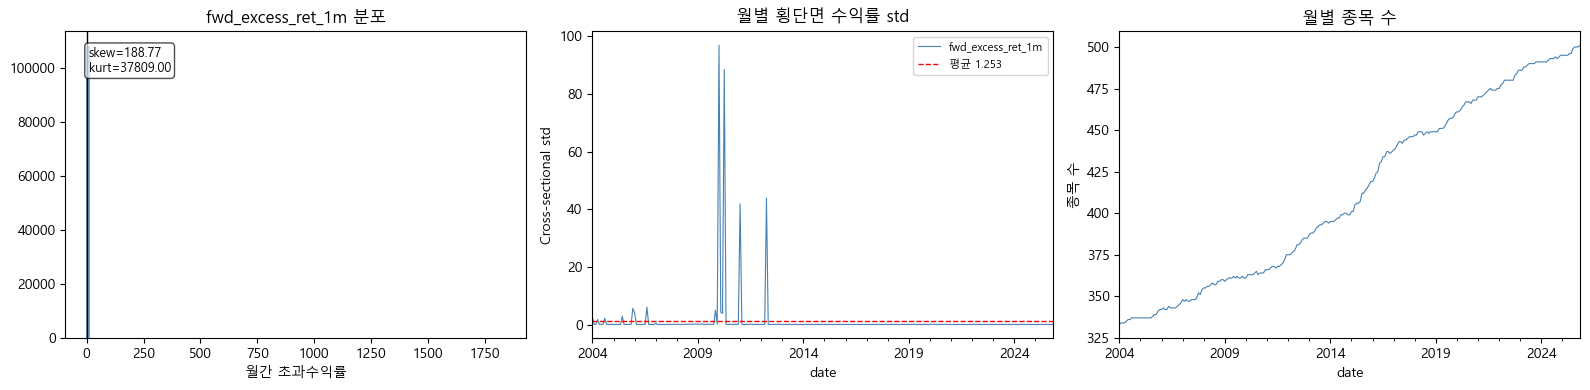

타겟 기초통계:
  관측수 : 108,328
  평균   : 0.0650
  std    : 8.4046
  skew   : 188.7714
  kurtosis: 37809.0043
  5%ile  : -0.1297
  95%ile : 0.1470

Jarque-Bera: stat=6452428141474.8  p=0.00e+00  → 정규분포 아님 → Huber 사용 정당

연도별 횡단면 std:
date
2004     1.1198
2005     1.8446
2006     2.1095
2007     0.1618
2008     0.1609
2009     1.4705
2010    37.8085
2011    12.0291
2012    12.6127
2013     0.0695
2014     0.0614
2015     0.0789
2016     0.0757
2017     0.0624
2018     0.0869
2019     0.0743
2020     0.1277
2021     0.0843
2022     0.1045
2023     0.0872
2024     0.0812
2025     0.0848


In [3]:
target_vals = df[TARGET].dropna()

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# 타겟 분포 히스토그램
axes[0].hist(target_vals, bins=120, color='steelblue', alpha=0.75, edgecolor='none')
axes[0].axvline(0, color='k', linewidth=1)
skew_val = float(target_vals.skew())
kurt_val = float(target_vals.kurtosis())
axes[0].set_title('fwd_excess_ret_1m 분포')
axes[0].set_xlabel('월간 초과수익률')
axes[0].text(0.05, 0.95, f'skew={skew_val:.2f}\nkurt={kurt_val:.2f}',
             transform=axes[0].transAxes, va='top', fontsize=9,
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

# 월별 횡단면 std
cs_std_ts = df.groupby(level='date')[TARGET].std()
cs_std_ts.plot(ax=axes[1], color='steelblue', linewidth=0.8)
axes[1].axhline(cs_std_ts.mean(), color='red', linestyle='--', linewidth=1,
                label=f'평균 {cs_std_ts.mean():.3f}')
axes[1].set_title('월별 횡단면 수익률 std')
axes[1].set_ylabel('Cross-sectional std')
axes[1].legend(fontsize=8)

# 월별 종목 수
n_stocks_ts = df.groupby(level='date')['ticker'].count()
n_stocks_ts.plot(ax=axes[2], color='steelblue', linewidth=0.8)
axes[2].set_title('월별 종목 수')
axes[2].set_ylabel('종목 수')

plt.tight_layout()
plt.show()

print('타겟 기초통계:')
print(f'  관측수 : {len(target_vals):,}')
print(f'  평균   : {target_vals.mean():.4f}')
print(f'  std    : {target_vals.std():.4f}')
print(f'  skew   : {skew_val:.4f}')
print(f'  kurtosis: {kurt_val:.4f}')
print(f'  5%ile  : {target_vals.quantile(0.05):.4f}')
print(f'  95%ile : {target_vals.quantile(0.95):.4f}')
print()
jb_stat, jb_p = scipy_stats.jarque_bera(target_vals)
print(f'Jarque-Bera: stat={jb_stat:.1f}  p={jb_p:.2e}  '
      f'→ {"정규분포 아님 → Huber 사용 정당" if jb_p < 0.05 else "정규분포 기각 못함"}')
print()
print('연도별 횡단면 std:')
print(df.groupby(df.index.year)[TARGET].std().rename('cs_std').round(4).to_string())

---
## Section 2. 피처 정의 & 정규화

- **주식 피처**: 날짜별 횡단면 rank → [-1, 1]  (GKX 방식)
- **매크로 피처**: rolling z-score (252일, lookahead 없음)

In [4]:
META = ['ticker', 'gics_sector']
# TARGET은 setup 셀에서 정의

# 주식 피처 (횡단면 rank 정규화)
_STOCK_CANDIDATE = [
    'mom_1w', 'mom_1m', 'mom_3m', 'mom_6m', 'mom_12m',
    'mom_12m_skip_1m', 'chmom', 'indmom',
    'vol_20d', 'vol_60d', 'vol_252d',
    'beta_252d', 'idiovol_21d', 'ivol_63d',
    'dollar_vol_21d', 'amihud_21d', 'log_mcap',
    'high52w_ratio', 'low52w_ratio', 'maxret_21d',
    'ma_gap_20_60', 'rsi_14', 'bb_pct',
    'intraday_range', 'vol_surge', 'autocorr_21d',
    'sharpe_21d', 'sharpe_63d', 'sortino_63d', 'ir_63d',
    'skew_63d', 'kurt_63d', 'mdd_252d',
    'rate_sensitivity', 'avg_corr',
]

# 매크로 피처 (rolling z-score)
_MACRO_CANDIDATE = [
    'wti_crude', 'gold', 'silver', 'vix', 'dxy',
    'skew_idx', 'copper', 't10y2y', 'icsa', 'sahm',
    'cpi', 'unrate',
]

STOCK_FEATS = [c for c in _STOCK_CANDIDATE if c in df.columns]
MACRO_FEATS = [c for c in _MACRO_CANDIDATE if c in df.columns]
ALL_FEATS   = STOCK_FEATS + MACRO_FEATS

print(f'주식 피처 : {len(STOCK_FEATS)}개')
print(f'매크로 피처: {len(MACRO_FEATS)}개')
print(f'전체 피처  : {len(ALL_FEATS)}개')

주식 피처 : 35개
매크로 피처: 12개
전체 피처  : 47개


In [ ]:
def cs_rank_norm(group: pd.DataFrame, cols: list) -> pd.DataFrame:
    """횡단면 rank → [-1, 1]"""
    out = group.copy()
    for c in cols:
        if c not in out.columns:
            continue
        s     = out[c]
        valid = s.notna()
        n     = valid.sum()
        if n < 2:
            continue
        ranked = s[valid].rank(method='average')
        out.loc[valid, c] = 2 * (ranked - 1) / (n - 1) - 1
    return out


def rolling_zscore(series: pd.Series, window: int = 252, min_periods: int = 63) -> pd.Series:
    """rolling z-score (lookahead 없음)"""
    mu  = series.rolling(window, min_periods=min_periods).mean()
    sig = series.rolling(window, min_periods=min_periods).std()
    return (series - mu) / sig.replace(0, np.nan)


# 매크로: 날짜당 하나의 값 → 대표 시계열 추출 후 rolling z-score
# window=36(3년), min_periods=12(1년) — 월별 데이터 기준 (일별 252/63과 다름)
macro_ts = df[~df.index.duplicated(keep='first')][MACRO_FEATS].sort_index()
macro_z  = macro_ts.apply(rolling_zscore, window=36, min_periods=12)

# 작업 데이터프레임 구성
df_work = df[META + [TARGET] + STOCK_FEATS].copy()
for col in MACRO_FEATS:
    df_work[col] = df_work.index.map(macro_z[col])

# 주식 피처: 날짜별 횡단면 rank → [-1, 1]
print('횡단면 rank 정규화 중...')
df_norm = (
    df_work
    .groupby(level='date', group_keys=False)
    .apply(lambda g: cs_rank_norm(g, STOCK_FEATS))
)

nan_pct = df_norm[ALL_FEATS].isna().mean().sort_values(ascending=False)
print(f'\n정규화 완료: {df_norm.shape}')
print('NaN 비율 (상위 10):')
print(nan_pct.head(10).round(4))

횡단면 rank 정규화 중...

정규화 완료: (108328, 50)
NaN 비율 (상위 10):
indmom              0.0995
ivol_63d            0.0546
idiovol_21d         0.0474
vol_252d            0.0437
chmom               0.0437
mom_12m_skip_1m     0.0437
mom_12m             0.0437
beta_252d           0.0437
rate_sensitivity    0.0414
low52w_ratio        0.0406
dtype: float64


Feature raw IC 계산 중...


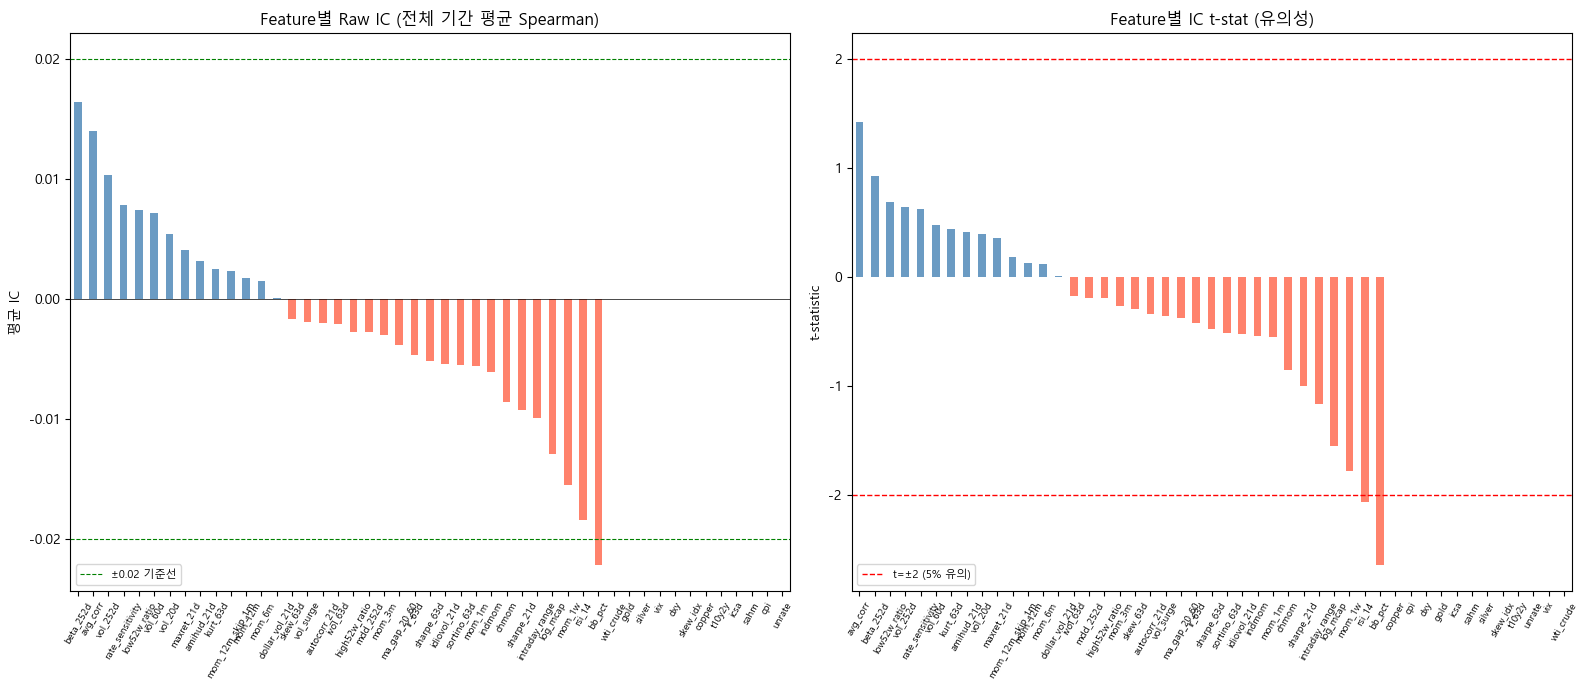

IC t-stat > +2.0 (유의 양의): 0개  → []
IC t-stat < -2.0 (유의 음의): 2개  → ['bb_pct', 'rsi_14']
유의하지 않은 feature       : 33개

Top 10 (IC 기준):
                mean_IC  t_stat
amihud_21d       0.0032  0.4144
autocorr_21d    -0.0021 -0.3410
avg_corr         0.0140  1.4218
bb_pct          -0.0222 -2.6465
beta_252d        0.0164  0.9264
chmom           -0.0086 -0.8556
copper              NaN     NaN
cpi                 NaN     NaN
dollar_vol_21d   0.0000  0.0057
dxy                 NaN     NaN


In [6]:
# Feature별 raw IC — 횡단면 Spearman(feature, target)을 날짜별로 구해 평균
# 전체 기간 기준 (모델링 전 사전 필터링 근거)
print('Feature raw IC 계산 중...')
raw_ic_records = {feat: [] for feat in ALL_FEATS}

for date, grp in df_norm.groupby(level='date'):
    for feat in ALL_FEATS:
        sub = grp[[feat, TARGET]].dropna()
        if len(sub) >= 20:
            ic_val, _ = spearmanr(sub[feat], sub[TARGET])
            raw_ic_records[feat].append(ic_val)

raw_ic_mean = pd.Series({f: np.nanmean(v) for f, v in raw_ic_records.items()}).sort_values(ascending=False)
raw_ic_std  = pd.Series({f: np.nanstd(v)  for f, v in raw_ic_records.items()})
raw_ic_n    = pd.Series({f: len(v)         for f, v in raw_ic_records.items()})

# t-stat (각 feature의 IC가 0과 유의하게 다른가)
raw_ic_tstat = raw_ic_mean / (raw_ic_std / np.sqrt(raw_ic_n))

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# 전체 feature raw IC 막대
colors = ['steelblue' if v >= 0 else 'tomato' for v in raw_ic_mean]
raw_ic_mean.plot(kind='bar', ax=axes[0], color=colors, alpha=0.8)
axes[0].axhline(0, color='k', linewidth=0.5)
axes[0].axhline(0.02,  color='green', linestyle='--', linewidth=0.8, label='±0.02 기준선')
axes[0].axhline(-0.02, color='green', linestyle='--', linewidth=0.8)
axes[0].set_title('Feature별 Raw IC (전체 기간 평균 Spearman)')
axes[0].set_ylabel('평균 IC')
axes[0].legend(fontsize=8)
axes[0].tick_params(axis='x', rotation=60, labelsize=7)

# t-stat 기준 정렬
tstat_sorted = raw_ic_tstat.sort_values(ascending=False)
colors2 = ['steelblue' if v >= 0 else 'tomato' for v in tstat_sorted]
tstat_sorted.plot(kind='bar', ax=axes[1], color=colors2, alpha=0.8)
axes[1].axhline(2.0,  color='red', linestyle='--', linewidth=1, label='t=±2 (5% 유의)')
axes[1].axhline(-2.0, color='red', linestyle='--', linewidth=1)
axes[1].set_title('Feature별 IC t-stat (유의성)')
axes[1].set_ylabel('t-statistic')
axes[1].legend(fontsize=8)
axes[1].tick_params(axis='x', rotation=60, labelsize=7)

plt.tight_layout()
plt.show()

# 유의미한 feature 요약
sig_pos  = raw_ic_tstat[raw_ic_tstat >  2.0].index.tolist()
sig_neg  = raw_ic_tstat[raw_ic_tstat < -2.0].index.tolist()
insig    = raw_ic_tstat[raw_ic_tstat.abs() <= 2.0].index.tolist()

print(f'IC t-stat > +2.0 (유의 양의): {len(sig_pos)}개  → {sig_pos}')
print(f'IC t-stat < -2.0 (유의 음의): {len(sig_neg)}개  → {sig_neg}')
print(f'유의하지 않은 feature       : {len(insig)}개')
print()
print('Top 10 (IC 기준):')
summary = pd.DataFrame({'mean_IC': raw_ic_mean, 't_stat': raw_ic_tstat}).head(10)
print(summary.round(4).to_string())

---
## Section 3. Walk-Forward Fold 생성

- **방식**: Expanding window (GKX) — 훈련 데이터가 매년 1년치씩 누적
- **최소 훈련 기간**: 3년
- **테스트 기간**: 연단위 슬라이딩
- **GAP**: train 종료 ~ test 시작 사이 21일 (overlapping label 방지)

In [7]:
TRAIN_START  = '2005-01-01'
MIN_TRAIN_YR = 3
GAP_DAYS     = 21

all_dates = sorted(df_norm.index.unique())
all_dates = [d for d in all_dates if d >= pd.Timestamp(TRAIN_START)]
year_set  = sorted(set(d.year for d in all_dates))

# 구조: Train(2005~t-2) → Val(t-1) → Test(t)
folds = []
for yr in year_set:
    test_start = pd.Timestamp(f'{yr}-01-01')
    test_end   = pd.Timestamp(f'{yr}-12-31')
    val_start  = pd.Timestamp(f'{yr-1}-01-01')
    val_end    = pd.Timestamp(f'{yr-1}-12-31')

    # train: val_start 21일 전까지 (label overlap 방지)
    train_cutoff = val_start - pd.Timedelta(days=GAP_DAYS)

    train_dates = [d for d in all_dates if d < train_cutoff]
    val_dates   = [d for d in all_dates if val_start <= d <= val_end]
    test_dates  = [d for d in all_dates if test_start <= d <= test_end]

    if len(train_dates) < MIN_TRAIN_YR * 12 or not val_dates or not test_dates:
        continue

    folds.append({'year': yr, 'train': train_dates, 'val': val_dates, 'test': test_dates})

print(f'Walk-forward fold: {len(folds)}개')
print('  {:>6}  {:>20}  {:>14}  {:>6}'.format('연도', 'train 기간', 'val 기간', 'test'))
for f in folds:
    tr_s = min(f['train']).strftime('%Y-%m')
    tr_e = max(f['train']).strftime('%Y-%m')
    va_s = min(f['val']).strftime('%Y-%m')
    va_e = max(f['val']).strftime('%Y-%m')
    print(f"  {f['year']:>6}  {tr_s}~{tr_e}  {va_s}~{va_e}  ({len(f['test'])}개)")

Walk-forward fold: 16개
      연도              train 기간          val 기간    test
    2010  2005-01~2008-11  2009-01~2009-12  (12개)
    2011  2005-01~2009-11  2010-01~2010-12  (12개)
    2012  2005-01~2010-11  2011-01~2011-12  (12개)
    2013  2005-01~2011-11  2012-01~2012-12  (12개)
    2014  2005-01~2012-11  2013-01~2013-12  (12개)
    2015  2005-01~2013-11  2014-01~2014-12  (12개)
    2016  2005-01~2014-11  2015-01~2015-12  (12개)
    2017  2005-01~2015-11  2016-01~2016-12  (12개)
    2018  2005-01~2016-11  2017-01~2017-12  (12개)
    2019  2005-01~2017-11  2018-01~2018-12  (12개)
    2020  2005-01~2018-11  2019-01~2019-12  (12개)
    2021  2005-01~2019-11  2020-01~2020-12  (12개)
    2022  2005-01~2020-11  2021-01~2021-12  (12개)
    2023  2005-01~2021-11  2022-01~2022-12  (12개)
    2024  2005-01~2022-11  2023-01~2023-12  (12개)
    2025  2005-01~2023-11  2024-01~2024-12  (11개)


---
## Section 4. XGBoost Walk-Forward 훈련

In [8]:
N_TRIALS = 30


def make_objective(X_tr, y_tr, X_val, y_val, seed):
    """Optuna objective: val Huber loss 최소화 (BL Q 절댓값 스케일 보존)."""
    def objective(trial):
        params = dict(
            objective        = 'reg:pseudohubererror',
            n_estimators     = trial.suggest_int('n_estimators', 50, 500),
            max_depth        = trial.suggest_int('max_depth', 2, 6),
            learning_rate    = trial.suggest_float('learning_rate', 0.01, 0.1, log=True),
            subsample        = trial.suggest_float('subsample', 0.5, 1.0),
            colsample_bytree = trial.suggest_float('colsample_bytree', 0.3, 0.8),
            min_child_weight = trial.suggest_int('min_child_weight', 5, 50),
            reg_lambda       = 1.0,
            reg_alpha        = 0.1,
            tree_method      = 'hist',
            random_state     = seed,
            n_jobs           = -1,
            verbosity        = 0,
            eval_metric      = 'mphe',
        )
        model = xgb.XGBRegressor(**params)
        model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
        val_loss = model.evals_result()['validation_0']['mphe'][-1]
        return val_loss
    return objective


def pseudo_huber_loss(y_true, y_pred, delta=1.0):
    """XGBoost reg:pseudohubererror와 동일한 공식 (delta=1)."""
    resid = y_true - y_pred
    return float(np.mean(delta**2 * (np.sqrt(1 + (resid / delta)**2) - 1)))


oos_parts        = []
feat_imp_sum     = pd.Series(0.0, index=ALL_FEATS)
fold_metrics     = []
best_params_log  = []

for fold in folds:
    yr = fold['year']

    tr = df_norm[df_norm.index.isin(fold['train'])].dropna(subset=ALL_FEATS + [TARGET])
    va = df_norm[df_norm.index.isin(fold['val'])].dropna(subset=ALL_FEATS + [TARGET])
    te = df_norm[df_norm.index.isin(fold['test'])].dropna(subset=ALL_FEATS + [TARGET])

    if len(tr) < 300 or len(va) == 0 or len(te) == 0:
        print(f'  {yr}: 데이터 부족 (train={len(tr)}, val={len(va)}, test={len(te)}) → 스킵')
        continue

    X_tr,  y_tr  = tr[ALL_FEATS].values, tr[TARGET].values
    X_val, y_val = va[ALL_FEATS].values, va[TARGET].values
    X_te,  y_te  = te[ALL_FEATS].values, te[TARGET].values

    # ── Optuna: val Huber loss 최소화 ──
    study = optuna.create_study(
        direction = 'minimize',
        sampler   = optuna.samplers.TPESampler(seed=RANDOM_SEED),
    )
    study.optimize(
        make_objective(X_tr, y_tr, X_val, y_val, RANDOM_SEED),
        n_trials          = N_TRIALS,
        show_progress_bar = False,
    )

    bp = study.best_params
    best_params_log.append({'year': yr, 'best_val_loss': study.best_value, **bp})

    # ── 최종 모델: train+val 합쳐서 best params로 재학습 ──
    X_tv = np.vstack([X_tr, X_val])
    y_tv = np.concatenate([y_tr, y_val])

    final_model = xgb.XGBRegressor(
        objective        = 'reg:pseudohubererror',
        n_estimators     = bp['n_estimators'],
        max_depth        = bp['max_depth'],
        learning_rate    = bp['learning_rate'],
        subsample        = bp['subsample'],
        colsample_bytree = bp['colsample_bytree'],
        min_child_weight = bp['min_child_weight'],
        reg_lambda       = 1.0,
        reg_alpha        = 0.1,
        tree_method      = 'hist',
        random_state     = RANDOM_SEED,
        n_jobs           = -1,
        verbosity        = 0,
    )
    final_model.fit(X_tv, y_tv)

    y_pred = final_model.predict(X_te)

    feat_imp_sum += pd.Series(final_model.feature_importances_, index=ALL_FEATS)

    te_out         = te[META + [TARGET]].copy()
    te_out['pred'] = y_pred
    oos_parts.append(te_out)

    ic         = spearmanr(y_te, y_pred)[0]
    ss_res     = ((y_te - y_pred) ** 2).sum()
    ss_tot     = (y_te ** 2).sum()
    r2         = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
    test_huber = pseudo_huber_loss(y_te, y_pred)

    fold_metrics.append({'year': yr, 'IC': ic, 'R2_OOS': r2, 'Huber_loss': test_huber, 'n': len(te)})
    print(f'  {yr}: test_ic={ic:+.4f}  R²={r2:+.4f}  huber={test_huber:.6f} │ '
          f'val_loss={study.best_value:.6f}  lr={bp["learning_rate"]:.3f}  '
          f'depth={bp["max_depth"]}  trees={bp["n_estimators"]}')

oos_df     = pd.concat(oos_parts).sort_index()
metrics_df = pd.DataFrame(fold_metrics).set_index('year')
params_df  = pd.DataFrame(best_params_log).set_index('year')

print(f'\nOOS 전체: {oos_df.shape[0]:,}행')
print('\n=== 연도별 최적 하이퍼파라미터 ===')
print(params_df.round(6))

  2010: test_ic=+0.3086  R²=+0.0852  huber=0.003796 │ val_loss=0.010965  lr=0.018  depth=6  trees=65
  2011: test_ic=-0.0615  R²=-0.0067  huber=0.003929 │ val_loss=0.003577  lr=0.027  depth=6  trees=405
  2012: test_ic=+0.1552  R²=-0.2068  huber=0.003212 │ val_loss=0.003656  lr=0.016  depth=5  trees=371
  2013: test_ic=+0.0625  R²=-0.0526  huber=0.002423 │ val_loss=0.002475  lr=0.018  depth=6  trees=65
  2014: test_ic=+0.0087  R²=-0.0269  huber=0.001815 │ val_loss=0.001987  lr=0.020  depth=2  trees=291
  2015: test_ic=+0.0999  R²=-0.1057  huber=0.003372 │ val_loss=0.001660  lr=0.010  depth=3  trees=223
  2016: test_ic=-0.2041  R²=+0.0092  huber=0.003002 │ val_loss=0.003256  lr=0.014  depth=6  trees=91
  2017: test_ic=-0.1014  R²=+0.0256  huber=0.001951 │ val_loss=0.002795  lr=0.013  depth=5  trees=91
  2018: test_ic=+0.0781  R²=-0.0424  huber=0.003885 │ val_loss=0.001896  lr=0.013  depth=2  trees=109
  2019: test_ic=-0.0920  R²=-0.0687  huber=0.003012 │ val_loss=0.003693  lr=0.030  dep

---
## Section 5. 성과 평가

- **R²_OOS**: GKX 기준 (분모 = 0, 나이브 예측 대비)
- **IC**: Spearman rank 상관계수 (예측 vs 실제)
- **ICIR**: IC / IC_std

In [9]:
# IC 시계열 (날짜별) — 그래프용으로만 사용
ic_ts = (
    oos_df.groupby(level='date')
    .apply(lambda g: spearmanr(g[TARGET], g['pred'])[0] if len(g) >= 5 else np.nan)
    .rename('IC')
)

# 전체 R²_OOS (pooled)
y_all = oos_df[TARGET].values
p_all = oos_df['pred'].values
r2_total = 1 - ((y_all - p_all) ** 2).sum() / (y_all ** 2).sum()

# fold 단위 IC 요약
fold_ic    = metrics_df['IC']
ic_fold_mean  = fold_ic.mean()
ic_fold_std   = fold_ic.std()
ic_fold_icir  = ic_fold_mean / ic_fold_std
ic_fold_pos   = (fold_ic > 0).mean()

# fold 단위 Huber loss 요약
fold_huber = metrics_df['Huber_loss']

print('=== OOS 성과 요약 ===')
print(f'R²_OOS (전체 pooled) : {r2_total:+.4f}  ({r2_total*100:+.2f}%)')
print()
print('--- Fold 단위 IC (연도별, 신뢰 가능) ---')
print(f'IC 평균              : {ic_fold_mean:+.4f}')
print(f'IC std               : {ic_fold_std:.4f}')
print(f'ICIR                 : {ic_fold_icir:+.4f}')
print(f'IC > 0 비율          : {ic_fold_pos:.1%}  ({int(ic_fold_pos*len(fold_ic))}/{len(fold_ic)}년)')
print()
print('--- Fold 단위 Huber Loss (test set, BL Q 스케일 신뢰도) ---')
print(f'Huber loss 평균      : {fold_huber.mean():.6f}')
print(f'Huber loss std       : {fold_huber.std():.6f}')
print(f'Huber loss 최솟값    : {fold_huber.min():.6f}  ({fold_huber.idxmin()}년)')
print(f'Huber loss 최댓값    : {fold_huber.max():.6f}  ({fold_huber.idxmax()}년)')
print()
print(metrics_df.round(6))

=== OOS 성과 요약 ===
R²_OOS (전체 pooled) : -0.0616  (-6.16%)

--- Fold 단위 IC (연도별, 신뢰 가능) ---
IC 평균              : +0.0189
IC std               : 0.1457
ICIR                 : +0.1299
IC > 0 비율          : 62.5%  (10/16년)

--- Fold 단위 Huber Loss (test set, BL Q 스케일 신뢰도) ---
Huber loss 평균      : 0.003775
Huber loss std       : 0.001749
Huber loss 최솟값    : 0.001815  (2014년)
Huber loss 최댓값    : 0.009196  (2020년)

            IC    R2_OOS  Huber_loss     n
year                                      
2010  0.308557  0.085232    0.003796  3182
2011 -0.061530 -0.006678    0.003929  3871
2012  0.155166 -0.206818    0.003212  3987
2013  0.062450 -0.052622    0.002423  4146
2014  0.008746 -0.026894    0.001815  4216
2015  0.099857 -0.105723    0.003372  4319
2016 -0.204143  0.009188    0.003002  4152
2017 -0.101399  0.025630    0.001951  4576
2018  0.078144 -0.042356    0.003885  5089
2019 -0.091951 -0.068708    0.003012  5315
2020 -0.213228 -0.150639    0.009196  5529
2021  0.037100  0.050172    0.00

---
## Section 5.5. 통계적 유의성 검정

- **IC t-test**: fold 단위 IC 시리즈가 0과 유의하게 다른가
- **유효 N 보정**: IC 자기상관이 있으면 실제 독립 관측치 수가 줄어듦
- **나이브 벤치마크**: 단일 모멘텀(mom_1m) IC와 모델 IC 비교
- **Val→Test 전이**: val IC 높은 fold가 test IC도 높은가 (튜닝 신뢰성)

In [10]:
fold_ic = metrics_df['IC']
n_folds = len(fold_ic)

# ── 1. IC t-test ──
t_stat, p_val = scipy_stats.ttest_1samp(fold_ic, 0)

# ── 2. 유효 N 보정 (lag-1 자기상관 반영) ──
ic_autocorr = fold_ic.autocorr(lag=1)
if abs(ic_autocorr) < 0.99:
    n_eff = n_folds * (1 - ic_autocorr) / (1 + ic_autocorr)
else:
    n_eff = 1.0
t_stat_eff = fold_ic.mean() / (fold_ic.std() / np.sqrt(max(n_eff, 1)))

# ── 3. 나이브 벤치마크: mom_1m 단일 feature IC ──
naive_ics = []
for date, grp in df_norm.groupby(level='date'):
    sub = grp[['mom_1m', TARGET]].dropna()
    if len(sub) >= 20:
        ic_naive, _ = spearmanr(sub['mom_1m'], sub[TARGET])
        naive_ics.append(ic_naive)
naive_ic_mean = float(np.nanmean(naive_ics))
naive_ic_std  = float(np.nanstd(naive_ics))

# ── 4. 결과 출력 ──
print('=' * 50)
print('  IC 통계적 유의성 검정')
print('=' * 50)
print(f'  n_folds        : {n_folds}')
print(f'  mean IC        : {fold_ic.mean():+.4f}')
print(f'  std  IC        : {fold_ic.std():.4f}')
print(f'  t-stat (naive) : {t_stat:+.3f}   p={p_val:.3f}')
print(f'  IC lag-1 자기상관: {ic_autocorr:.3f}')
print(f'  유효 N (n_eff) : {n_eff:.1f}')
print(f'  t-stat (보정)  : {t_stat_eff:+.3f}')
print()

criteria = [
    ('t-stat > 2.0',    abs(t_stat)    > 2.0),
    ('t-stat(eff) > 1.65', abs(t_stat_eff) > 1.65),
    ('hit rate > 55%',  (fold_ic > 0).mean() > 0.55),
    ('mean IC > 0.03',  fold_ic.mean()     > 0.03),
    ('ICIR > 0.5',      fold_ic.mean() / fold_ic.std() > 0.5),
]
print('  최소 기준 체크:')
for name, passed in criteria:
    mark = '✓' if passed else '✗'
    print(f'    {mark}  {name}')

print()
print('=' * 50)
print('  나이브 벤치마크 (mom_1m 단일) vs 모델')
print('=' * 50)
print(f'  나이브 평균 IC : {naive_ic_mean:+.4f}  (std={naive_ic_std:.4f})')
print(f'  모델  평균 IC  : {fold_ic.mean():+.4f}  (std={fold_ic.std():.4f})')
beat = fold_ic.mean() > naive_ic_mean
print(f'  모델 > 나이브  : {"✓ 맞음" if beat else "✗ 나이브보다 못함"}')
print(f'  초과 IC        : {fold_ic.mean() - naive_ic_mean:+.4f}')

  IC 통계적 유의성 검정
  n_folds        : 16
  mean IC        : +0.0189
  std  IC        : 0.1457
  t-stat (naive) : +0.519   p=0.611
  IC lag-1 자기상관: -0.037
  유효 N (n_eff) : 17.2
  t-stat (보정)  : +0.539

  최소 기준 체크:
    ✗  t-stat > 2.0
    ✗  t-stat(eff) > 1.65
    ✓  hit rate > 55%
    ✗  mean IC > 0.03
    ✗  ICIR > 0.5

  나이브 벤치마크 (mom_1m 단일) vs 모델
  나이브 평균 IC : -0.0056  (std=0.1626)
  모델  평균 IC  : +0.0189  (std=0.1457)
  모델 > 나이브  : ✓ 맞음
  초과 IC        : +0.0245


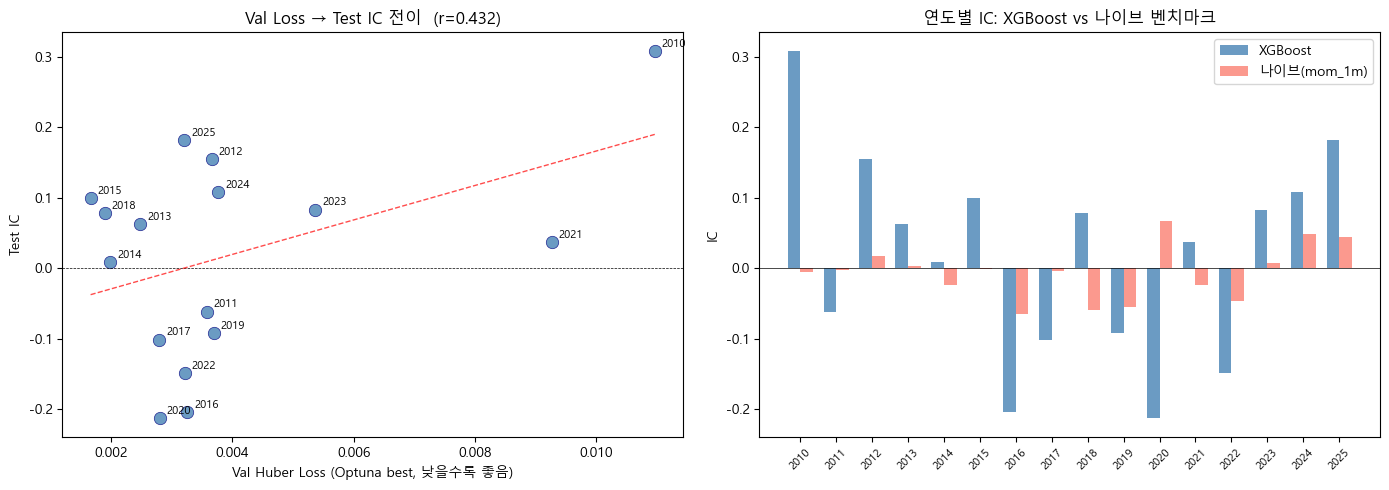

Val Loss → Test IC 상관계수: 0.432
  → val-test 전이 없음 (regime shift or overfitting 의심)


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Val Loss vs Test IC 산점도 ──
val_loss = params_df['best_val_loss']
test_ic  = metrics_df['IC']
corr_vt  = val_loss.corr(test_ic)

axes[0].scatter(val_loss, test_ic, color='steelblue', s=80, alpha=0.8,
                edgecolors='navy', linewidth=0.5)
for yr in val_loss.index:
    axes[0].annotate(str(yr), (val_loss[yr], test_ic[yr]),
                     textcoords='offset points', xytext=(5, 3), fontsize=8)
axes[0].axhline(0, color='k', linewidth=0.5, linestyle='--')
axes[0].set_xlabel('Val Huber Loss (Optuna best, 낮을수록 좋음)')
axes[0].set_ylabel('Test IC')
axes[0].set_title(f'Val Loss → Test IC 전이  (r={corr_vt:.3f})')

if abs(corr_vt) > 0.01:
    z = np.polyfit(val_loss, test_ic, 1)
    xline = np.linspace(val_loss.min(), val_loss.max(), 50)
    axes[0].plot(xline, np.polyval(z, xline), 'r--', linewidth=1, alpha=0.7)

# ── fold별 IC 시각화 (모델 vs 나이브) ──
naive_ic_yearly = []
for yr, fold in zip([f['year'] for f in folds], folds):
    yr_ics = []
    for date, grp in df_norm[df_norm.index.isin(fold['test'])].groupby(level='date'):
        sub = grp[['mom_1m', TARGET]].dropna()
        if len(sub) >= 20:
            ic_n, _ = spearmanr(sub['mom_1m'], sub[TARGET])
            yr_ics.append(ic_n)
    naive_ic_yearly.append({'year': yr, 'naive_ic': np.nanmean(yr_ics) if yr_ics else np.nan})

naive_yr_df = pd.DataFrame(naive_ic_yearly).set_index('year')

years = metrics_df.index
x = np.arange(len(years))
w = 0.35
axes[1].bar(x - w/2, metrics_df['IC'],        width=w, label='XGBoost',        color='steelblue', alpha=0.8)
axes[1].bar(x + w/2, naive_yr_df['naive_ic'], width=w, label='나이브(mom_1m)', color='salmon',    alpha=0.8)
axes[1].axhline(0, color='k', linewidth=0.5)
axes[1].set_xticks(x)
axes[1].set_xticklabels(years, rotation=45, fontsize=8)
axes[1].set_title('연도별 IC: XGBoost vs 나이브 벤치마크')
axes[1].set_ylabel('IC')
axes[1].legend()

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'xgb_IC_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Val Loss → Test IC 상관계수: {corr_vt:.3f}')
if corr_vt < -0.3:
    print('  → val loss 낮을수록 test IC 높음 (튜닝이 test로 잘 전이됨)')
elif corr_vt < 0:
    print('  → 약한 음의 전이 (val loss 튜닝의 신뢰도 제한적)')
else:
    print('  → val-test 전이 없음 (regime shift or overfitting 의심)')

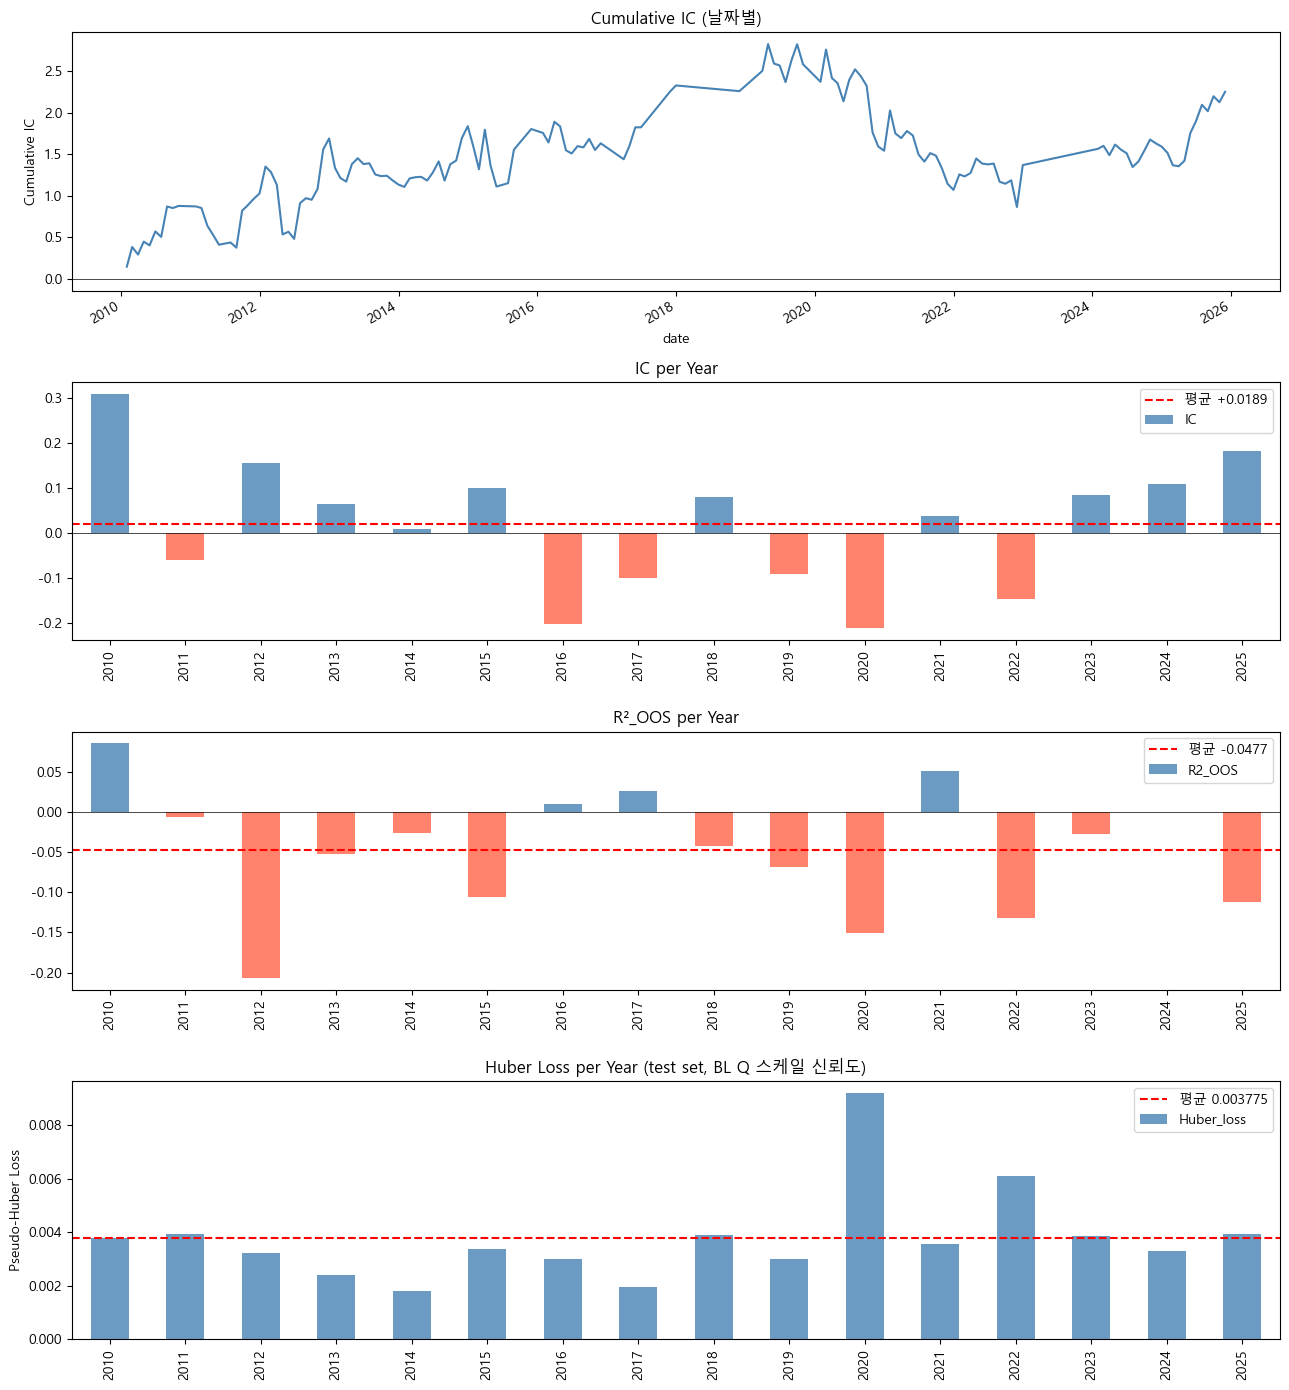

In [12]:
fig, axes = plt.subplots(4, 1, figsize=(13, 14))

# 누적 IC
ic_ts.dropna().cumsum().plot(ax=axes[0], color='steelblue')
axes[0].set_title('Cumulative IC (날짜별)')
axes[0].axhline(0, color='k', linewidth=0.5)
axes[0].set_ylabel('Cumulative IC')

# 연도별 IC
colors = ['steelblue' if v >= 0 else 'tomato' for v in metrics_df['IC']]
metrics_df['IC'].plot(kind='bar', ax=axes[1], color=colors, alpha=0.8)
axes[1].set_title('IC per Year')
axes[1].axhline(0, color='k', linewidth=0.5)
axes[1].axhline(metrics_df['IC'].mean(), color='red', linestyle='--',
                label=f'평균 {metrics_df["IC"].mean():+.4f}')
axes[1].legend()
axes[1].set_xlabel('')

# 연도별 R²_OOS
colors2 = ['steelblue' if v >= 0 else 'tomato' for v in metrics_df['R2_OOS']]
metrics_df['R2_OOS'].plot(kind='bar', ax=axes[2], color=colors2, alpha=0.8)
axes[2].set_title('R²_OOS per Year')
axes[2].axhline(0, color='k', linewidth=0.5)
axes[2].axhline(metrics_df['R2_OOS'].mean(), color='red', linestyle='--',
                label=f'평균 {metrics_df["R2_OOS"].mean():+.4f}')
axes[2].legend()
axes[2].set_xlabel('')

# 연도별 Huber Loss (test set)
metrics_df['Huber_loss'].plot(kind='bar', ax=axes[3], color='steelblue', alpha=0.8)
axes[3].set_title('Huber Loss per Year (test set, BL Q 스케일 신뢰도)')
axes[3].axhline(metrics_df['Huber_loss'].mean(), color='red', linestyle='--',
                label=f'평균 {metrics_df["Huber_loss"].mean():.6f}')
axes[3].legend()
axes[3].set_xlabel('')
axes[3].set_ylabel('Pseudo-Huber Loss')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'xgb_IC_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

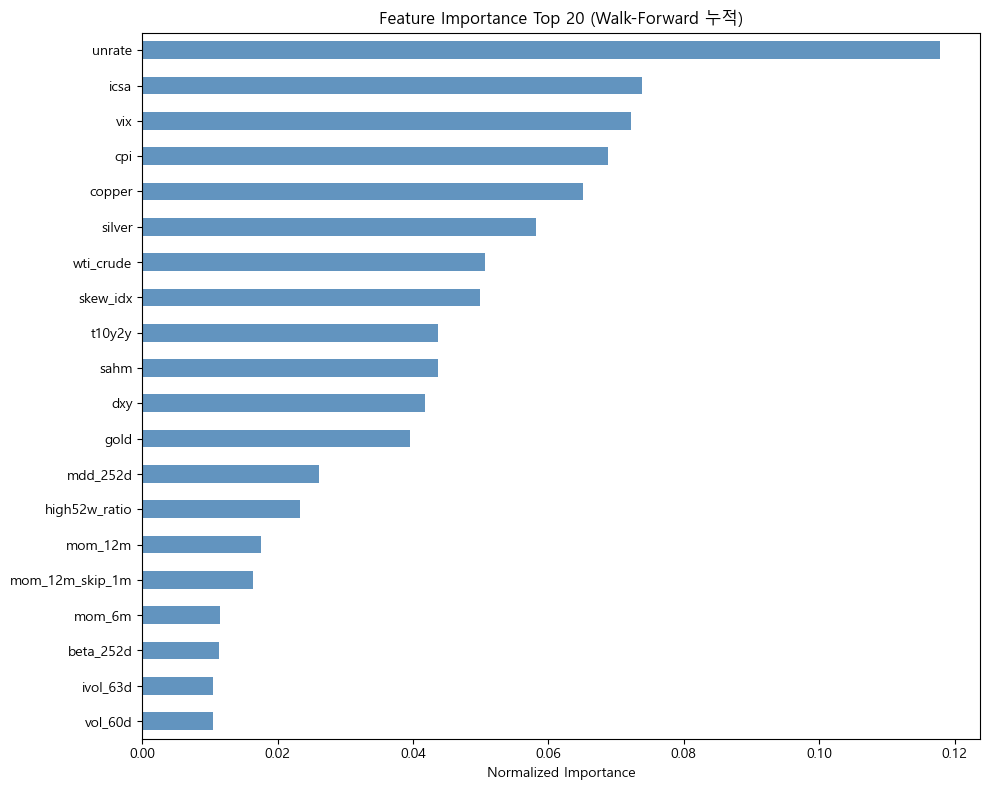

Top 10 피처:
unrate       0.1179
icsa         0.0738
vix          0.0723
cpi          0.0688
copper       0.0651
silver       0.0581
wti_crude    0.0506
skew_idx     0.0499
t10y2y       0.0438
sahm         0.0437
dtype: float64


In [13]:
feat_norm = feat_imp_sum / feat_imp_sum.sum()
top20     = feat_norm.sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(10, 8))
top20.sort_values().plot(kind='barh', ax=ax, color='steelblue', alpha=0.85)
ax.set_title('Feature Importance Top 20 (Walk-Forward 누적)')
ax.set_xlabel('Normalized Importance')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'xgb_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 10 피처:')
print(top20.head(10).round(4))

---
## Section 6. Q & Omega 생성 (Black-Litterman용)

| 변수 | 의미 |
|---|---|
| **Q** | 각 종목의 예측 초과수익률 벡터 (analyst views) |
| **Omega** | 예측 불확실성 — OOS 잔차 분산 대각행렬 |

In [14]:
oos_df

,ticker,gics_sector,fwd_excess_ret_1m,pred
date,,,,
2010-01-31,HRL,Consumer Staples,0.080879,0.017031
2010-01-31,FITB,Financials,0.017685,0.021295
2010-01-31,TXN,Information Technology,0.088000,0.021555
2010-01-31,LLY,Health Care,-0.004610,0.017886
2010-01-31,TFC,Financials,-0.002153,0.020289
...,...,...,...,...
2025-11-30,RJF,Financials,0.034184,0.051092
2025-11-30,PAYX,Industrials,0.011012,0.053152
2025-11-30,WM,Industrials,0.019241,0.051092


In [15]:
# 가장 최근 날짜의 cross-section → Q
last_date = oos_df.index.max()
last_cs   = oos_df.loc[last_date]

if isinstance(last_cs, pd.Series):
    last_cs = last_cs.to_frame().T

Q = last_cs.set_index('ticker')['pred'].rename('Q')

# Omega: 종목별 OOS 잔차 분산
oos_df['resid']  = oos_df[TARGET] - oos_df['pred']
omega_diag       = oos_df.groupby('ticker')['resid'].var().rename('omega')

print(f'Q 벡터: {len(Q)}종목  (기준일: {last_date.date()})')
print(f'\n예측 수익률 상위 10:')
print(Q.nlargest(10).round(4).to_frame())
print(f'\n예측 수익률 하위 10:')
print(Q.nsmallest(10).round(4).to_frame())
print(f'\nOmega 평균: {omega_diag.mean():.6f}')

Q 벡터: 498종목  (기준일: 2025-11-30)

예측 수익률 상위 10:
             Q
ticker        
SMCI    0.0626
FISV    0.0622
TTD     0.0612
MOH     0.0606
DECK    0.0598
LULU    0.0598
MRNA    0.0598
CNC     0.0598
IT      0.0596
ZBRA    0.0594

예측 수익률 하위 10:
             Q
ticker        
GEHC    0.0503
TFC     0.0503
GM      0.0503
NI      0.0503
FANG    0.0503
TKO     0.0503
HBAN    0.0503
USB     0.0503
PHM     0.0503
GPC     0.0503

Omega 평균: 0.009459


In [16]:
results = {
    'oos_df'    : oos_df,
    'metrics'   : metrics_df,
    'ic_ts'     : ic_ts,
    'feat_imp'  : feat_norm,
    'Q'         : Q,
    'omega'     : omega_diag,
    'ALL_FEATS' : ALL_FEATS,
}
with open(OUTPUT_DIR / 'xgb_results.pkl', 'wb') as f:
    pickle.dump(results, f)

oos_df.to_csv(OUTPUT_DIR / 'oos_predictions.csv')
metrics_df.to_csv(OUTPUT_DIR / 'fold_metrics.csv')
Q.to_csv(OUTPUT_DIR / 'Q_views.csv')
omega_diag.to_csv(OUTPUT_DIR / 'omega_diag.csv')

print('저장 완료:')
for f in OUTPUT_DIR.iterdir():
    print(f'  {f.name}')

저장 완료:
  fold_metrics.csv
  omega_diag.csv
  oos_predictions.csv
  Q_views.csv
  xgb_feature_importance.png
  xgb_IC_analysis.png
  xgb_IC_diagnostics.png
  xgb_results.pkl
